# Amazon Ecommerce Sales Analysis

This notebook reads `Amazon Ecommerce Dataset.csv` and performs reproducible exploratory data analysis. It never writes to or modifies the source CSV.

## Project Navigation

- **Source data:** `Amazon Ecommerce Dataset.csv`
- **Dependencies:** `requirements.txt`
- **Project guide:** `README.md`
- **Project report:** `Amazon_Ecommerce_Project_Report.docx`

Run the code cells from top to bottom. The notebook reads the source CSV, performs analysis in memory, and produces the tables and charts described in the report. It does not modify the CSV.

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid')

PROJECT_FILES = {
    'source data': Path('Amazon Ecommerce Dataset.csv'),
    'dependencies': Path('requirements.txt'),
    'project guide': Path('README.md'),
    'project report': Path('Amazon_Ecommerce_Project_Report.docx'),
}
DATA_PATH = PROJECT_FILES['source data']
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing source data: {DATA_PATH}. Keep the CSV in the same folder as this notebook."
    )
missing_companions = [name for name, path in PROJECT_FILES.items() if not path.exists()]
if missing_companions:
    print('Missing companion files:', ', '.join(missing_companions))
else:
    print('All project files are connected and available.')

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print(f'Rows: {len(df):,} | Columns: {len(df.columns)}')
df.head()

All project files are connected and available.
Rows: 100,000 | Columns: 20


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


## 1. Data quality and structure

In [14]:
print(df.info())
display(df.describe(include='all').T)
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique(dropna=False)
})
display(quality)
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate OrderIDs:', df['OrderID'].duplicated().sum() if 'OrderID' in df else 'OrderID not available')

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  str    
 1   OrderDate      100000 non-null  str    
 2   CustomerID     100000 non-null  str    
 3   CustomerName   100000 non-null  str    
 4   ProductID      100000 non-null  str    
 5   ProductName    100000 non-null  str    
 6   Category       100000 non-null  str    
 7   Brand          100000 non-null  str    
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  str    
 15  OrderStatus    100000 non-null  str    
 16  City           100000 non-null  str    
 17  State          100000 non-null  str    
 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrderID,100000,100000,ORD0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderDate,100000,1825,2022-04-28,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,100000,43233,CUST023748,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerName,100000,200,Karan Joshi,556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductID,100000,50,P00019,2098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductName,100000,50,LED Desk Lamp,2098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,100000,6,Electronics,16853,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,100000,10,ReadMore,10204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"100,000.00",NaN,NaN,NaN,3.00,1.41,1.00,2.00,3.00,4.00,5.00
UnitPrice,"100,000.00",NaN,NaN,NaN,302.91,171.84,5.00,154.19,303.07,451.50,599.99


,dtype,missing,missing_pct,unique_values
OrderID,str,0,0.00,100000
OrderDate,str,0,0.00,1825
CustomerID,str,0,0.00,43233
CustomerName,str,0,0.00,200
ProductID,str,0,0.00,50
ProductName,str,0,0.00,50
Category,str,0,0.00,6
Brand,str,0,0.00,10
Quantity,int64,0,0.00,5
UnitPrice,float64,0,0.00,48433


Duplicate rows: 0
Duplicate OrderIDs: 0


In [15]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
numeric_columns = ['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')
print('Date range:', df['OrderDate'].min().date(), 'to', df['OrderDate'].max().date())
invalid_numeric = (df[numeric_columns] < 0).sum().rename('negative_values')
display(invalid_numeric.to_frame())
df['calculated_amount_before_tax_shipping'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])
df['calculated_total'] = df['calculated_amount_before_tax_shipping'] + df['Tax'] + df['ShippingCost']
df['total_amount_difference'] = df['TotalAmount'] - df['calculated_total']
print('Rows with total difference above 0.05:', (df['total_amount_difference'].abs() > 0.05).sum())

Date range: 2020-01-01 to 2024-12-29


,negative_values
Quantity,0
UnitPrice,0
Discount,0
Tax,0
ShippingCost,0
TotalAmount,0


Rows with total difference above 0.05: 0


## 2. Feature engineering and core KPIs

In [6]:
df['Year'] = df['OrderDate'].dt.year
df['Quarter'] = df['OrderDate'].dt.to_period('Q').astype(str)
df['Month'] = df['OrderDate'].dt.to_period('M').astype(str)
df['DiscountAmount'] = df['Quantity'] * df['UnitPrice'] * df['Discount']
df['OrderValueExcludingTaxShipping'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])
kpis = pd.Series({
    'Total recorded sales': df['TotalAmount'].sum(),
    'Total orders': df['OrderID'].nunique(),
    'Total units sold': df['Quantity'].sum(),
    'Average order value': df['TotalAmount'].mean(),
    'Average units per order': df['Quantity'].mean(),
    'Unique customers': df['CustomerID'].nunique(),
    'Unique products': df['ProductID'].nunique(),
    'Unique sellers': df['SellerID'].nunique()
})
display(kpis.to_frame('Value'))
status_summary = df.groupby('OrderStatus').agg(Orders=('OrderID','nunique'), Sales=('TotalAmount','sum'), Units=('Quantity','sum')).sort_values('Sales', ascending=False)
display(status_summary)

,Value
Total recorded sales,"91,825,647.92"
Total orders,"100,000.00"
Total units sold,"300,140.00"
Average order value,918.26
Average units per order,3.00
Unique customers,"43,233.00"
Unique products,50.00
Unique sellers,"1,999.00"


,Orders,Sales,Units
OrderStatus,,,
Delivered,74628,"68,372,677.10",223759
Shipped,15192,"14,083,628.99",45660
Pending,4103,"3,737,556.98",12338
Cancelled,3028,"2,851,122.39",9242
Returned,3049,"2,780,662.46",9141


## 3. Time, category, brand, and product analysis

In [7]:
monthly = df.groupby('Month').agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), Units=('Quantity','sum')).reset_index()
category_summary = df.groupby('Category').agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), Units=('Quantity','sum'), AverageOrderValue=('TotalAmount','mean')).sort_values('Sales', ascending=False)
brand_summary = df.groupby('Brand').agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), Units=('Quantity','sum')).sort_values('Sales', ascending=False)
product_summary = df.groupby(['ProductID','ProductName']).agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), Units=('Quantity','sum'), AveragePrice=('UnitPrice','mean')).sort_values('Sales', ascending=False)
display(monthly.tail(12)); display(category_summary); display(brand_summary.head(15)); display(product_summary.head(15))

,Month,Sales,Orders,Units
48,2024-01,"1,493,946.70",1679,4997
49,2024-02,"1,412,146.91",1562,4692
50,2024-03,"1,548,280.27",1740,5124
51,2024-04,"1,511,151.55",1647,4942
52,2024-05,"1,642,609.94",1753,5306
53,2024-06,"1,541,772.48",1671,5131
54,2024-07,"1,469,460.10",1631,4833
55,2024-08,"1,577,272.85",1731,5184
56,2024-09,"1,468,209.92",1613,4735
57,2024-10,"1,520,332.67",1642,4997


,Sales,Orders,Units,AverageOrderValue
Category,,,,
Electronics,"15,584,217.18",16853,50696,924.71
Sports & Outdoors,"15,345,571.88",16804,50543,913.21
Books,"15,261,837.01",16752,49981,911.05
Clothing,"15,253,397.50",16439,49523,927.88
Toys & Games,"15,216,684.99",16542,49773,919.88
Home & Kitchen,"15,163,939.36",16610,49624,912.94


,Sales,Orders,Units
Brand,,,
CoreTech,"9,343,720.59",10127,30430
KiddoFun,"9,324,749.55",10077,30168
ReadMore,"9,278,406.63",10204,30421
UrbanStyle,"9,249,027.45",9854,30104
Zenith,"9,239,960.39",9990,30058
Apex,"9,147,604.72",9937,29955
NexPro,"9,078,824.97",9962,29791
FitLife,"9,061,444.68",10147,30121
BrightLux,"9,056,816.11",9907,29616


,,Sales,Orders,Units,AveragePrice
ProductID,ProductName,,,,
P00047,Memory Card 128GB,"1,935,138.40",2039,6240,307.71
P00019,LED Desk Lamp,"1,921,948.41",2098,6344,298.77
P00007,Mechanical Keyboard,"1,906,963.54",2034,6161,306.60
P00017,Electric Kettle,"1,905,751.79",2054,6165,304.35
P00010,Smartwatch,"1,901,275.59",1989,5983,312.79
P00030,Dress Shirt,"1,896,765.36",2007,5960,312.31
P00022,Water Bottle,"1,895,467.95",2088,6275,300.16
P00006,Gaming Mouse,"1,895,103.98",2010,6170,303.37
P00031,Kids Toy Car,"1,891,082.43",2004,6131,305.98


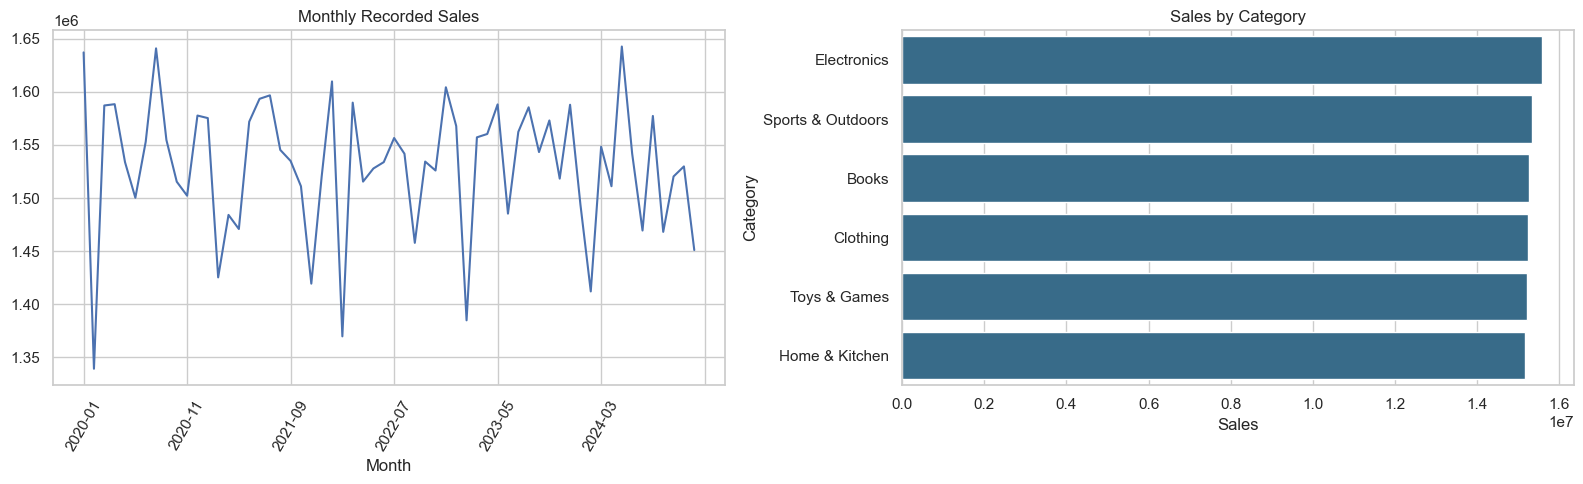

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
monthly.plot(x='Month', y='Sales', ax=axes[0], title='Monthly Recorded Sales', legend=False)
axes[0].tick_params(axis='x', rotation=60)
sns.barplot(data=category_summary.reset_index(), y='Category', x='Sales', ax=axes[1], color='#2a6f97')
axes[1].set_title('Sales by Category')
plt.tight_layout()
plt.show()

## 4. Customer, seller, payment, and geography analysis

In [10]:
customer_summary = df.groupby(['CustomerID','CustomerName']).agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), Units=('Quantity','sum'), LastOrder=('OrderDate','max')).sort_values('Sales', ascending=False)
seller_summary = df.groupby('SellerID').agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), Units=('Quantity','sum'), AverageOrderValue=('TotalAmount','mean')).sort_values('Sales', ascending=False)
payment_summary = df.groupby('PaymentMethod').agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), AverageOrderValue=('TotalAmount','mean')).sort_values('Sales', ascending=False)
country_summary = df.groupby('Country').agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), Units=('Quantity','sum')).sort_values('Sales', ascending=False)
state_summary = df.groupby(['Country','State']).agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique')).sort_values('Sales', ascending=False)
display(customer_summary.head(15)); display(seller_summary.head(15)); display(payment_summary); display(country_summary); display(state_summary.head(20))

,,Sales,Orders,Units,LastOrder
CustomerID,CustomerName,,,,
CUST010696,Pooja Patel,"5,436.04",2,10,2023-01-28
CUST035973,Neha Sharma,"5,124.43",2,9,2021-03-12
CUST009614,Vikas Mehta,"5,003.65",2,9,2023-10-24
CUST018720,Arjun Kapoor,"4,773.18",2,9,2024-02-23
CUST022824,Pooja Joshi,"4,755.48",2,8,2024-04-11
CUST008882,Sneha Reddy,"4,730.47",2,9,2024-08-29
CUST022031,Priya Kapoor,"4,266.02",2,7,2024-09-04
CUST031449,Vivaan Kapoor,"4,253.27",2,8,2022-12-17
CUST005523,Sahil Patel,"4,239.18",2,10,2024-10-22


,Sales,Orders,Units,AverageOrderValue
SellerID,,,,
SELL00806,"71,283.67",67,234,"1,063.94"
SELL00440,"71,062.59",61,197,"1,164.96"
SELL01225,"70,785.92",61,204,"1,160.42"
SELL00709,"70,491.92",69,223,"1,021.62"
SELL00221,"70,446.50",65,211,"1,083.79"
SELL01122,"69,469.40",67,217,"1,036.86"
SELL00994,"69,400.06",61,199,"1,137.71"
SELL00536,"69,248.00",70,220,989.26
SELL00371,"69,118.88",65,203,"1,063.37"


,Sales,Orders,AverageOrderValue
PaymentMethod,,,
Credit Card,"32,122,158.69",35038,916.78
Debit Card,"18,538,678.53",20024,925.82
UPI,"13,896,028.55",15066,922.34
Amazon Pay,"13,697,498.42",15017,912.13
Net Banking,"9,055,674.57",9927,912.23
Cash on Delivery,"4,515,609.16",4928,916.32


,Sales,Orders,Units
Country,,,
United States,"64,310,048.50",70058,210409
India,"13,875,839.12",15051,45082
Canada,"5,323,757.00",5818,17381
United Kingdom,"4,526,896.86",4943,14831
Australia,"3,789,106.44",4130,12437


Sales  Orders
Country        State                      
United States  TX    15,897,488.53   17334
               CA    12,783,662.94   14014
India          TX     3,503,209.66    3797
United States  NC     3,311,877.73    3606
               PA     3,287,459.93    3543
               FL     3,281,693.36    3594
               IL     3,268,618.39    3507
               IN     3,246,583.55    3469
               CO     3,240,143.04    3462
               OH     3,237,947.84    3521
               WA     3,224,396.33    3504
               DC     3,197,914.23    3560
               AZ     3,182,720.17    3503
               NY     3,149,542.46    3441
India          CA     2,832,945.31    3041
Canada         TX     1,354,480.31    1500
United Kingdom TX     1,114,570.99    1221
Canada         CA     1,044,107.78    1120
Australia      TX       992,791.05    1044
United Kingdom CA       851,806.02     964

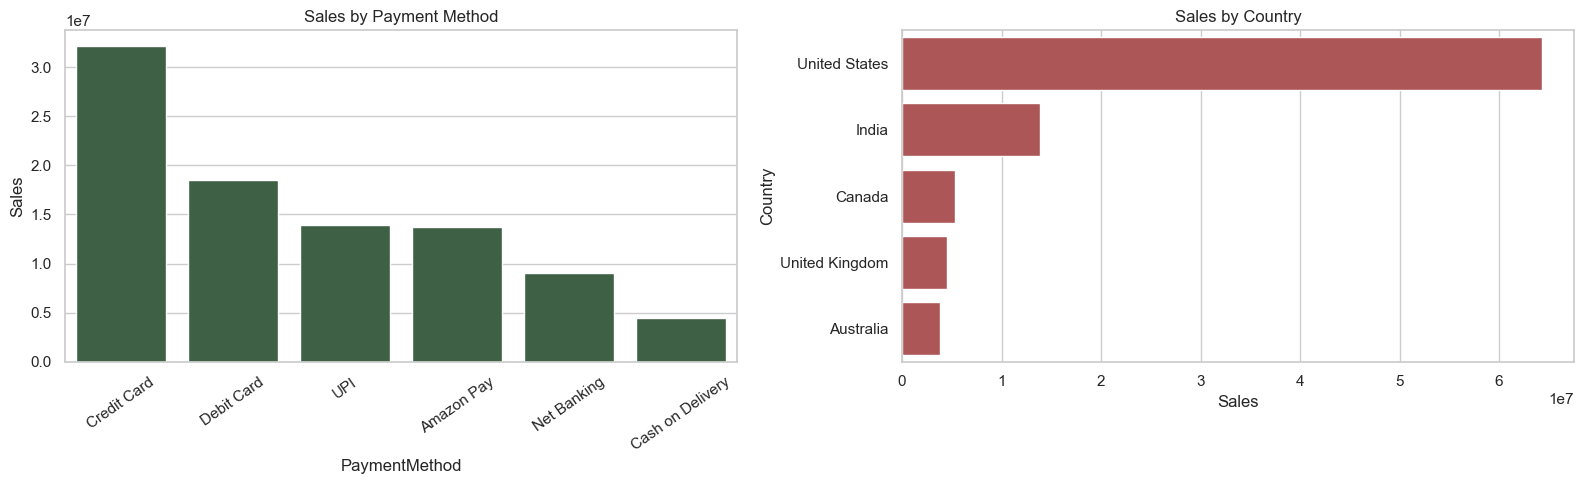

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=payment_summary.reset_index(), x='PaymentMethod', y='Sales', ax=axes[0], color='#386641')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_title('Sales by Payment Method')
sns.barplot(data=country_summary.reset_index(), y='Country', x='Sales', ax=axes[1], color='#bc4749')
axes[1].set_title('Sales by Country')
plt.tight_layout()
plt.show()

## 5. Discount, tax, shipping, and final review

In [12]:
discount_summary = df.groupby('Discount').agg(Sales=('TotalAmount','sum'), Orders=('OrderID','nunique'), Units=('Quantity','sum'), AverageOrderValue=('TotalAmount','mean')).sort_index()
print('Average discount amount:', df['DiscountAmount'].mean())
display(discount_summary)
print('Top categories by average order value')
display(category_summary.sort_values('AverageOrderValue', ascending=False).head(10))
print('Order status percentages')
display((df['OrderStatus'].value_counts(normalize=True) * 100).round(2).rename('Percent'))
print('Analysis complete. Review data-quality flags before using the KPIs for decisions.')

Average discount amount: 67.83119186500001


,Sales,Orders,Units,AverageOrderValue
Discount,,,,
0.00,"39,759,304.30",40246,120977,987.91
0.05,"18,754,249.73",19889,59570,942.95
0.10,"13,391,000.91",14910,44711,898.12
0.15,"8,451,571.63",10041,30114,841.71
0.20,"6,301,022.17",7939,23766,793.68
0.25,"3,723,201.49",4986,14939,746.73
0.30,"1,445,297.69",1989,6063,726.65


Top categories by average order value


,Sales,Orders,Units,AverageOrderValue
Category,,,,
Clothing,"15,253,397.50",16439,49523,927.88
Electronics,"15,584,217.18",16853,50696,924.71
Toys & Games,"15,216,684.99",16542,49773,919.88
Sports & Outdoors,"15,345,571.88",16804,50543,913.21
Home & Kitchen,"15,163,939.36",16610,49624,912.94
Books,"15,261,837.01",16752,49981,911.05


Order status percentages


OrderStatus
Delivered   74.63
Shipped     15.19
Pending      4.10
Returned     3.05
Cancelled    3.03
Name: Percent, dtype: float64

Analysis complete. Review data-quality flags before using the KPIs for decisions.
